# MyHoliday — Destination Dataset Exploration & Merging
**Purpose:** Explore Dataset 1 (560 cities) and Dataset 3 (111 cities), check how many match, then produce a final merged destination table.

---

## Cell 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import json
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Cell 2 — Load Datasets


In [3]:
# ── Update these paths ──────────────────────────────────────
PATH_DATASET1 = 'Worldwide Travel Cities Dataset (Ratings and Climate).csv'   # City metadata + thematic ratings
PATH_DATASET2 = 'Travel details dataset.csv'   # Historical trip records
PATH_DATASET3 = 'travel_destinations.csv'   # Categories + best time to visit
# ────────────────────────────────────────────────────────────

df1 = pd.read_csv(PATH_DATASET1)
df2 = pd.read_csv(PATH_DATASET2)
df3 = pd.read_csv(PATH_DATASET3)

print(f'Dataset 1 shape : {df1.shape}')
print(f'Dataset 2 shape : {df2.shape}')
print(f'Dataset 3 shape : {df3.shape}')

Dataset 1 shape : (560, 19)
Dataset 2 shape : (139, 13)
Dataset 3 shape : (111, 4)


## Cell 3 — Inspect Dataset 1

In [4]:
print('=== DATASET 1 — Columns ===')
print(df1.columns.tolist())
print()
df1.head(5)

=== DATASET 1 — Columns ===
['id', 'city', 'country', 'region', 'short_description', 'latitude', 'longitude', 'avg_temp_monthly', 'ideal_durations', 'budget_level', 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion']



,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, historic arch...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg"":7.1,""max...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vibrant cora...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""avg"":28,""max...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a serene escap...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""avg"":-1.8,""...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facades create ...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""avg"":17.2,""...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,"Bustling streets filled with the aroma of local spices, ...",-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""avg"":27.8,...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2


In [5]:
print('=== DATASET 1 — Data Types ===')
print(df1.dtypes)
print()
print('=== DATASET 1 — Missing Values ===')
print(df1.isnull().sum())

=== DATASET 1 — Data Types ===
id                    object
city                  object
country               object
region                object
short_description     object
latitude             float64
longitude            float64
avg_temp_monthly      object
ideal_durations       object
budget_level          object
culture                int64
adventure              int64
nature                 int64
beaches                int64
nightlife              int64
cuisine                int64
wellness               int64
urban                  int64
seclusion              int64
dtype: object

=== DATASET 1 — Missing Values ===
id                   0
city                 0
country              0
region               0
short_description    0
latitude             0
longitude            0
avg_temp_monthly     0
ideal_durations      0
budget_level         0
culture              0
adventure            0
nature               0
beaches              0
nightlife            0
cuisine              0


## Cell 4 — Inspect Dataset 2

In [6]:
print('=== DATASET 2 — Columns ===')
print(df2.columns.tolist())
print()
df2.head(5)

=== DATASET 2 — Columns ===
['Trip ID', 'Destination', 'Start date', 'End date', 'Duration (days)', 'Traveler name', 'Traveler age', 'Traveler gender', 'Traveler nationality', 'Accommodation type', 'Accommodation cost', 'Transportation type', 'Transportation cost']



,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [7]:
print('=== DATASET 2 — Data Types ===')
print(df2.dtypes)
print()
print('=== DATASET 2 — Missing Values ===')
print(df2.isnull().sum())

=== DATASET 2 — Data Types ===
Trip ID                   int64
Destination              object
Start date               object
End date                 object
Duration (days)         float64
Traveler name            object
Traveler age            float64
Traveler gender          object
Traveler nationality     object
Accommodation type       object
Accommodation cost       object
Transportation type      object
Transportation cost      object
dtype: object

=== DATASET 2 — Missing Values ===
Trip ID                 0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64


## Cell 5 — Inspect Dataset 3

In [8]:
print('=== DATASET 3 — Columns ===')
print(df3.columns.tolist())
print()
df3.head(5)

=== DATASET 3 — Columns ===
['City', 'Country', 'Category', 'Best_Time_to_Travel']



,City,Country,Category,Best_Time_to_Travel
0,London,United Kingdom,"history, culture, museums, theatre, shopping, landmarks,...","Apr, May, Jun, Sep, Oct"
1,Paris,France,"art, museums, landmarks, culture, history, food, romance...","Apr, May, Jun, Sep, Oct"
2,Rome,Italy,"history, ancient ruins, culture, art, food, religion, la...","Apr, May, Jun, Sep, Oct"
3,Berlin,Germany,"history, culture, nightlife, art, museums, music","May, Jun, Jul, Aug, Sep"
4,Madrid,Spain,"art, museums, nightlife, food, culture, history, shopping","Apr, May, Jun, Sep, Oct"


In [9]:
print('=== DATASET 3 — Data Types ===')
print(df3.dtypes)
print()
print('=== DATASET 3 — Missing Values ===')
print(df3.isnull().sum())

=== DATASET 3 — Data Types ===
City                   object
Country                object
Category               object
Best_Time_to_Travel    object
dtype: object

=== DATASET 3 — Missing Values ===
City                   0
Country                0
Category               0
Best_Time_to_Travel    0
dtype: int64


## Cell 6 — Standardise City Names
Before matching, we clean city names: strip whitespace, lowercase, remove special characters.

> ⚠️ Update `city_col_d1` and `city_col_d3` below to match the actual column names in your datasets.

In [11]:
# ── Update column names to match your actual datasets ───────
city_col_d1 = 'city'    # Column name for city in Dataset 1
city_col_d3 = 'City'    # Column name for city in Dataset 3
# ────────────────────────────────────────────────────────────

def clean_city_name(s):
    if pd.isna(s):
        return ''
    return str(s).strip().lower()

df1['city_clean'] = df1[city_col_d1].apply(clean_city_name)
df3['city_clean'] = df3[city_col_d3].apply(clean_city_name)

print('Sample cleaned names — Dataset 1:')
print(df1['city_clean'].head(10).tolist())
print()
print('Sample cleaned names — Dataset 3:')
print(df3['city_clean'].head(10).tolist())

Sample cleaned names — Dataset 1:
['milan', 'yasawa islands', 'whistler', 'guanajuato', 'surabaya', 'nuuk', 'windhoek', 'kingston', 'nafplio', 'tbilisi']

Sample cleaned names — Dataset 3:
['london', 'paris', 'rome', 'berlin', 'madrid', 'prague', 'amsterdam', 'athens', 'lisbon', 'interlaken']


## Cell 7 — Check How Many Cities Match

In [12]:
d1_cities = set(df1['city_clean'])
d3_cities = set(df3['city_clean'])

matched     = d1_cities & d3_cities
only_in_d1  = d1_cities - d3_cities
only_in_d3  = d3_cities - d1_cities

print(f'Total cities in Dataset 1   : {len(d1_cities)}')
print(f'Total cities in Dataset 3   : {len(d3_cities)}')
print(f'Matched cities              : {len(matched)}')
print(f'Only in Dataset 1           : {len(only_in_d1)}')
print(f'Only in Dataset 3           : {len(only_in_d3)}')
print()
print('Cities only in Dataset 3 (not in Dataset 1):')
print(sorted(only_in_d3))

Total cities in Dataset 1   : 559
Total cities in Dataset 3   : 111
Matched cities              : 96
Only in Dataset 1           : 463
Only in Dataset 3           : 15

Cities only in Dataset 3 (not in Dataset 1):
['bali (denpasar/ubud)', 'cairns', 'cusco', 'da nang', 'ella', 'habarana', 'interlaken', 'jerusalem', 'mirissa', 'nice', 'phuket', 'salvador', 'santiago', 'washington d.c.', "xi'an"]


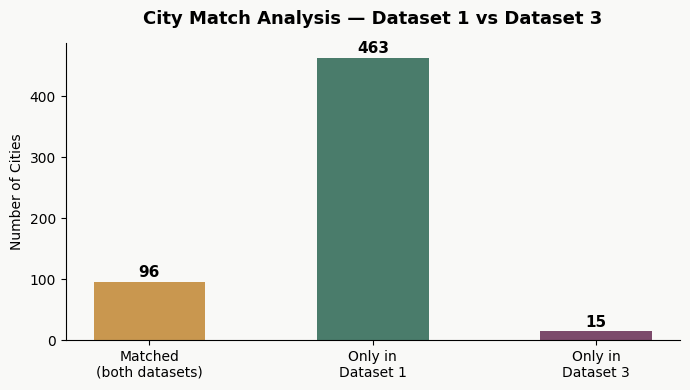

In [13]:
# Visualise match breakdown
labels  = ['Matched\n(both datasets)', 'Only in\nDataset 1', 'Only in\nDataset 3']
values  = [len(matched), len(only_in_d1), len(only_in_d3)]
colors  = ['#c9974f', '#4a7c6b', '#7c4a6b']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='none')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('City Match Analysis — Dataset 1 vs Dataset 3', fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Number of Cities')
ax.set_facecolor('#f9f9f7')
fig.patch.set_facecolor('#f9f9f7')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## Cell 8 — Decide Merge Strategy
Based on the match count above:
- **If matched >= 80** → Left Join on Dataset 1 (keep all 560, NULLs for unmatched)
- **If matched < 80** → Inner Join (keep only matched cities for complete data)

This cell will automatically recommend a strategy.

In [14]:
THRESHOLD = 80

if len(matched) >= THRESHOLD:
    strategy = 'left'
    print(f'✅ Recommendation: LEFT JOIN — Keep all {len(d1_cities)} cities from Dataset 1.')
    print(f'   {len(only_in_d1)} cities will have NULL for categories and best_time_to_visit.')
else:
    strategy = 'inner'
    print(f'⚠️  Recommendation: INNER JOIN — Only keep {len(matched)} matched cities.')
    print(f'   This ensures all cities have complete data.')

print(f'\nSelected strategy: {strategy.upper()} JOIN')

✅ Recommendation: LEFT JOIN — Keep all 559 cities from Dataset 1.
   463 cities will have NULL for categories and best_time_to_visit.

Selected strategy: LEFT JOIN


## Cell 9 — Perform the Merge (Dataset 1 + Dataset 3)


In [16]:
# ── Update column names to match your actual Dataset 3 ──────
category_col_d3   = 'Category'          # e.g. 'history, culture, museums'
besttime_col_d3   = 'Best_Time_to_Travel' # e.g. 'Apr, May, Jun'
# ────────────────────────────────────────────────────────────

# Select only needed columns from Dataset 3
df3_slim = df3[['city_clean', category_col_d3, besttime_col_d3]].copy()
df3_slim.columns = ['city_clean', 'categories', 'best_time_to_visit']

# Drop duplicates in Dataset 3 (keep first occurrence)
df3_slim = df3_slim.drop_duplicates(subset='city_clean', keep='first')

# Perform merge
df_merged = df1.merge(df3_slim, on='city_clean', how=strategy)

print(f'Merged dataset shape: {df_merged.shape}')
print(f'Null counts after merge:')
print(df_merged[['categories', 'best_time_to_visit']].isnull().sum())
df_merged.head(5)

Merged dataset shape: (560, 22)
Null counts after merge:
categories            464
best_time_to_visit    464
dtype: int64


,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion,city_clean,categories,best_time_to_visit
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, historic arch...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg"":7.1,""max...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2,milan,NaN,NaN
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vibrant cora...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""avg"":28,""max...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5,yasawa islands,NaN,NaN
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a serene escap...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""avg"":-1.8,""...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4,whistler,NaN,NaN
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facades create ...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""avg"":17.2,""...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2,guanajuato,NaN,NaN
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,"Bustling streets filled with the aroma of local spices, ...",-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""avg"":27.8,...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2,surabaya,NaN,NaN


## Cell 10 — Clean Dataset 2 (Historical Trips)

In [29]:
# ── Update column names to match your actual Dataset 2 ──────
cols_to_keep = [
    'Destination',
    'Duration (days)',
    'Traveler age',
    'Traveler gender',
    'Traveler nationality',
    'Accommodation type',
    'Accommodation cost',
    'Transportation type',
    'Transportation cost',
]
# ────────────────────────────────────────────────────────────

# Keep only useful columns
# Filter to only columns that exist (in case names differ slightly)
existing_cols = [c for c in cols_to_keep if c in df2.columns]
missing_cols  = [c for c in cols_to_keep if c not in df2.columns]

if missing_cols:
    print(f'⚠️  These columns were not found in Dataset 2 — update the names above:')
    print(missing_cols)

df2_clean = df2[existing_cols].copy()

# Standardise column names to snake_case
df2_clean.columns = (
    df2_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

# Fix accommodation_cost and transportation_cost to numeric
df2_clean['accommodation_cost'] = pd.to_numeric(df2_clean['accommodation_cost'], errors='coerce')
df2_clean['transportation_cost'] = pd.to_numeric(df2_clean['transportation_cost'], errors='coerce')

# Verify
print(df2_clean[['accommodation_cost', 'transportation_cost']].dtypes)
print(df2_clean[['accommodation_cost', 'transportation_cost']].isnull().sum())

# Drop rows with all nulls
df2_clean.dropna(how='all', inplace=True)

# Extract only the city name from 'destination'
if 'destination' in df2_clean.columns:
    df2_clean['destination'] = df2_clean['destination'].apply(lambda x: str(x).split(',')[0].strip() if pd.notna(x) else x)

print(f'Dataset 2 cleaned shape: {df2_clean.shape}')
print(f'Columns: {df2_clean.columns.tolist()}')
if 'destination' in df2_clean.columns:
    num_unique = df2_clean['destination'].nunique()
    print(f'Unique cities in Dataset 2: {num_unique}')
df2_clean.head(5)

accommodation_cost     float64
transportation_cost    float64
dtype: object
accommodation_cost     67
transportation_cost    68
dtype: int64
Dataset 2 cleaned shape: (137, 9)
Columns: ['destination', 'duration_days', 'traveler_age', 'traveler_gender', 'traveler_nationality', 'accommodation_type', 'accommodation_cost', 'transportation_type', 'transportation_cost']
Unique cities in Dataset 2: 39


,destination,duration_days,traveler_age,traveler_gender,traveler_nationality,accommodation_type,accommodation_cost,transportation_type,transportation_cost
0,London,7.0,35.0,Male,American,Hotel,1200.0,Flight,600.0
1,Phuket,5.0,28.0,Female,Canadian,Resort,800.0,Flight,500.0
2,Bali,7.0,45.0,Male,Korean,Villa,1000.0,Flight,700.0
3,New York,14.0,29.0,Female,British,Hotel,2000.0,Flight,1000.0
4,Tokyo,7.0,26.0,Female,Vietnamese,Airbnb,700.0,Train,200.0


## Cell 11 — Quick EDA on Merged Destination Table

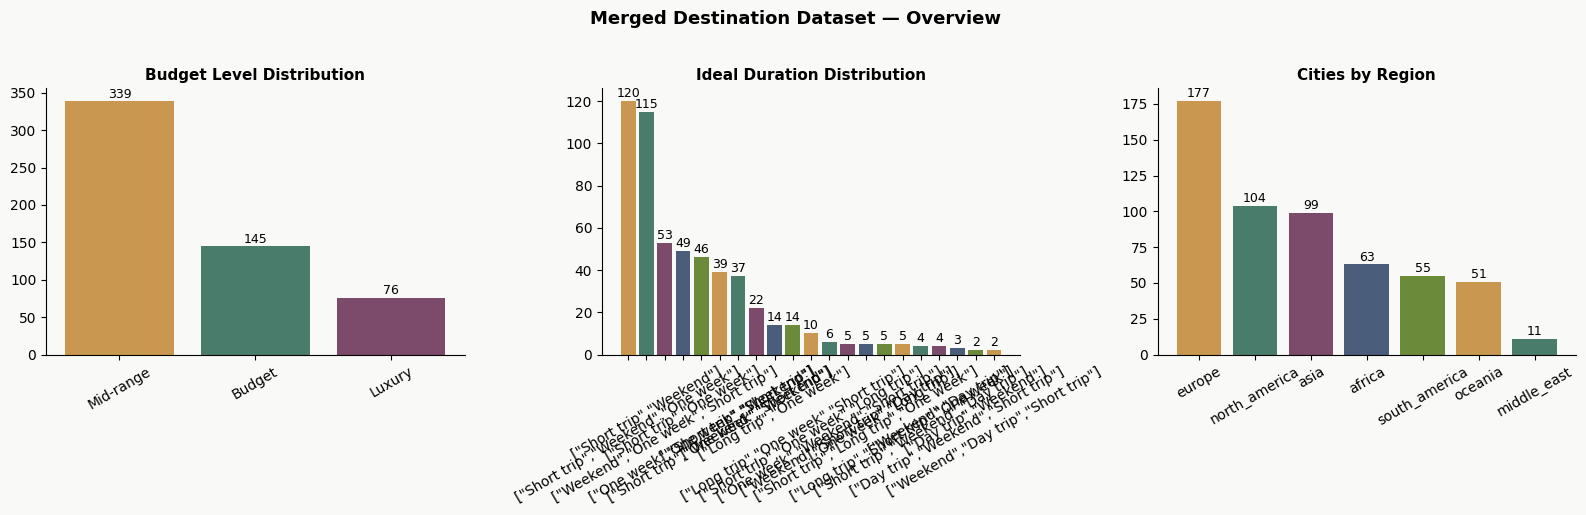

In [25]:
# ── Update these to match your actual column names ──────────
budget_col   = 'budget_level'   # 'Budget', 'Mid-range', 'Luxury'
duration_col = 'ideal_durations' # 'Weekend', 'Short trip', 'Long trip'
region_col   = 'region'
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f9f9f7')

palette = ['#c9974f', '#4a7c6b', '#7c4a6b', '#4a5e7c', '#6b8a3a']

for ax, col, title in zip(
    axes,
    [budget_col, duration_col, region_col],
    ['Budget Level Distribution', 'Ideal Duration Distribution', 'Cities by Region']
):
    if col in df_merged.columns:
        counts = df_merged[col].value_counts()
        bars = ax.bar(counts.index, counts.values,
                      color=palette[:len(counts)], edgecolor='none')
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=9)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_facecolor('#f9f9f7')
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(axis='x', rotation=30)
    else:
        ax.text(0.5, 0.5, f'Column "{col}" not found\nUpdate column name above',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(title)

plt.suptitle('Merged Destination Dataset — Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Cell 12 — Quick EDA on Historical Trips (Dataset 2)

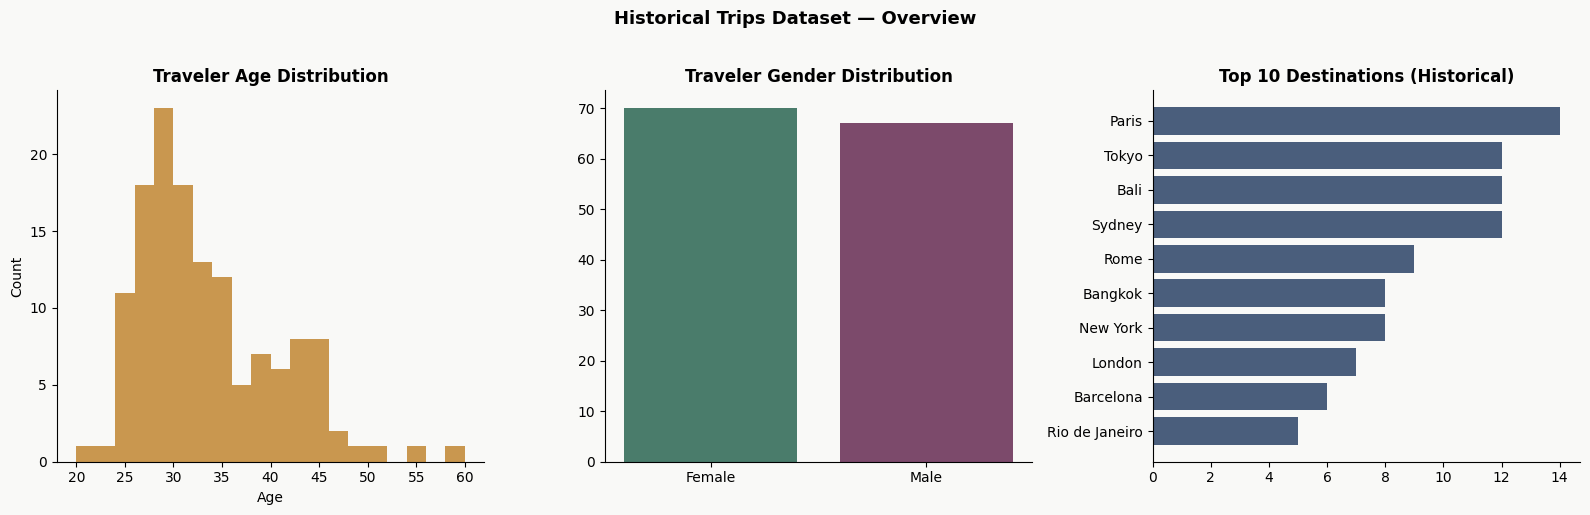

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f9f9f7')

# Age distribution
age_col = [c for c in df2_clean.columns if 'age' in c]
if age_col:
    axes[0].hist(df2_clean[age_col[0]].dropna(), bins=20, color='#c9974f', edgecolor='none')
    axes[0].set_title('Traveler Age Distribution', fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Count')
    axes[0].set_facecolor('#f9f9f7')
    axes[0].spines[['top','right']].set_visible(False)

# Gender distribution
gender_col = [c for c in df2_clean.columns if 'gender' in c]
if gender_col:
    counts = df2_clean[gender_col[0]].value_counts()
    axes[1].bar(counts.index, counts.values, color=['#4a7c6b','#7c4a6b'], edgecolor='none')
    axes[1].set_title('Traveler Gender Distribution', fontweight='bold')
    axes[1].set_facecolor('#f9f9f7')
    axes[1].spines[['top','right']].set_visible(False)

# Top 10 destinations
dest_col = [c for c in df2_clean.columns if 'destination' in c]
if dest_col:
    top_dest = df2_clean[dest_col[0]].value_counts().head(10)
    axes[2].barh(top_dest.index[::-1], top_dest.values[::-1], color='#4a5e7c', edgecolor='none')
    axes[2].set_title('Top 10 Destinations (Historical)', fontweight='bold')
    axes[2].set_facecolor('#f9f9f7')
    axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Historical Trips Dataset — Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Cell 13 — Final Cleanup & Rename Columns for Database
Standardise all column names to snake_case, ready for PostgreSQL import.

In [31]:
def to_snake_case(col):
    return (
        col.strip()
        .lower()
        .replace(' ', '_')
        .replace('-', '_')
        .replace('(', '')
        .replace(')', '')
    )

df_destinations = df_merged.copy()
df_destinations.drop(columns=['city_clean'], inplace=True)
df_destinations.columns = [to_snake_case(c) for c in df_destinations.columns]

df_historical_trips = df2_clean.copy()

print('=== Final Destination Table Columns ===')
print(df_destinations.columns.tolist())
print(f'Shape: {df_destinations.shape}')
print()
print('=== Final Historical Trips Table Columns ===')
print(df_historical_trips.columns.tolist())
print(f'Shape: {df_historical_trips.shape}')

=== Final Destination Table Columns ===
['id', 'city', 'country', 'region', 'short_description', 'latitude', 'longitude', 'avg_temp_monthly', 'ideal_durations', 'budget_level', 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion', 'categories', 'best_time_to_visit']
Shape: (560, 21)

=== Final Historical Trips Table Columns ===
['destination', 'duration_days', 'traveler_age', 'traveler_gender', 'traveler_nationality', 'accommodation_type', 'accommodation_cost', 'transportation_type', 'transportation_cost']
Shape: (137, 9)


## Cell 14 — Export Final CSVs

In [32]:
df_destinations.to_csv('destinations_final.csv', index=False)
df_historical_trips.to_csv('historical_trips_final.csv', index=False)

print('✅ Exported successfully:')
print('   destinations_final.csv      — import this into the destinations table in Supabase')
print('   historical_trips_final.csv  — import this into the historical_trips table in Supabase')

✅ Exported successfully:
   destinations_final.csv      — import this into the destinations table in Supabase
   historical_trips_final.csv  — import this into the historical_trips table in Supabase


---
## Summary

| Output File | Description | Import Into |
|---|---|---|
| `destinations_final.csv` | Merged Dataset 1 + 3 | `destinations` table |
| `historical_trips_final.csv` | Cleaned Dataset 2 | `historical_trips` table |

**Next step:** Use these CSVs to design your ERD and write your CREATE TABLE SQL scripts.